# SVM classifier 

Cancer Dataset

### Step 1: Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

### Step 2: Load and prepare the dataset


In [ ]:
# Download dataset from sklearn
"""
from sklearn import datasets
import pandas as pd

data = datasets.load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0:'malignant',1:'benign'})

df.to_csv("breast_cancer_dataset_full.csv", index=False)
"""
"""
data = datasets.load_breast_cancer()
X = data.data
y = data.target
"""

In [8]:
data = pd.read_csv("cancer.csv")

X = data.drop(['target','diagnosis'], axis=1)
y = data['target']

### Step 3: Split the dataset into training and testing sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Step 4: Feature scaling

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 5: Train an SVM classifier

In [11]:
svm_classifier = SVC(kernel='linear', C=1)
svm_classifier.fit(X_train, y_train)

SVC(C=1, kernel='linear')

### Step 6: Make predictions

In [12]:
y_pred = svm_classifier.predict(X_test)


### Step 7: Evaluate the model

In [13]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

### Step 8: Visualize results using PCA

In [14]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

In [15]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

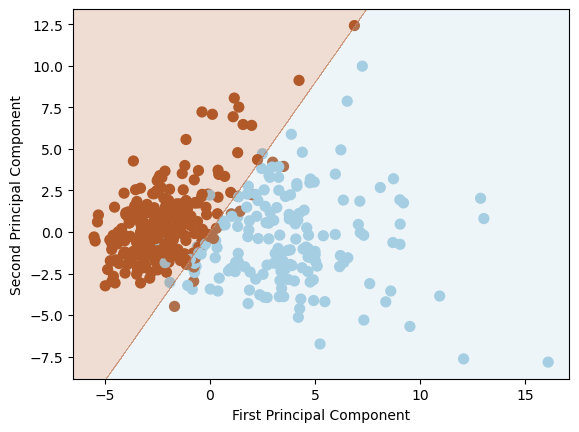

In [16]:
# Plot the training data
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.Paired, s=50, label="Training Data")
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Plot the decision boundary
h = .02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_classifier.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

### Step 9: Print results

In [17]:
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_rep)

Accuracy: 0.956140350877193
Confusion Matrix:
 [[41  2]
 [ 3 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



RBF – Radial Basis Function  

RBF is one of the kernels used in SVM (and other algorithms).  

What It Does  

RBF kernel transforms the original feature space into a higher-dimensional space.  

This allows non-linear separation of classes using a linear hyperplane in the new space.  

In simple terms: it lets SVM draw curved boundaries between classes.  

In [ ]:
# Trying RBF Kernel

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Non-linear SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')  # gamma='scale' is default
svm_rbf.fit(X_train, y_train)

y_pred = svm_rbf.predict(X_test)
print("Accuracy with RBF SVM:", accuracy_score(y_test, y_pred))

Accuracy with RBF SVM: 0.9824561403508771


| Kernel                | When to Use                           | Notes                                                        |
| --------------------- | ------------------------------------- | ------------------------------------------------------------ |
| **linear**            | Data is roughly linearly separable    | Fast, interpretable; you’re using this now                   |
| **poly** (polynomial) | Data has **polynomial relationships** | Can capture curved boundaries; may overfit if degree is high |
| **rbf** (Gaussian)    | Data has **non-linear clusters**      | Most commonly used; good default for non-linear separation   |
| **sigmoid**           | Similar to a 2-layer neural network   | Less common; rarely best on this dataset                     |
